# Exploratory Data Analysis 

#### Project framing and target definition

This project aims to predict risk of radon concentration greater than 200 Bq/m3 in FSAs across Canada.

Each row in the dataset represents a house-level observation.  
The training target is a binary indicator of whether the radon concentration exceeds 200 Bq/m3:

- 1: radon concentration > 200 Bq/m3
- 0: radon concentration ≤ 200 Bq/m3

Although the model is trained on house-level binary labels, project-level radon risk can be summarized at the FSA level by aggregating house-level labels or predictions within each FSA.

This notebook focuses on exploratory data analysis (EDA), including missingness, target distributions, representative feature-target relationships, and basic outlier checks. More formal feature reduction decisions are documented separately in `reduce_feature.ipynb`.

In [69]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# define project root
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
MAIN_DATASET = PROJECT_ROOT/"data"/"final_dataset"/"main_dataset.csv"

df_main = pd.read_csv(MAIN_DATASET)

In [70]:
df_main

,FSA,n_days,concentration,longitude,latitude,hous_frac_type_single_detached,hous_frac_type_highrise,hous_frac_type_other_attached,hous_frac_type_movable,hous_avg_rooms,...,sedi_glaciomarine_sediments,sedi_lacustrine_sediments,sedi_marine_sediments,sedi_organic_deposits,sedi_volcanic_deposits,sedi_weathered_bedrock_or_regolith,average_heating_days,mean_uranium,max_uranium,provinceterritory
0,A0A,127.0,20.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.000000,0.0,0.030408,0.000000,0.000000,0.0,305.532585,NaN,NaN,NL
1,A0A,108.0,36.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.000000,0.0,0.030408,0.000000,0.000000,0.0,305.532585,NaN,NaN,NL
2,A0E,91.0,7.5,-54.777629,47.384855,0.933854,0.000521,0.055208,0.010417,6.9,...,0.122135,0.0,0.125665,0.000000,0.000000,0.0,326.720975,0.637329,3.509083,NL
3,A0A,91.0,31.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.000000,0.0,0.030408,0.000000,0.000000,0.0,305.532585,NaN,NaN,NL
4,A0C,98.0,26.0,-53.725413,48.375277,0.933988,0.000000,0.052632,0.013381,6.6,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,293.239321,0.846531,2.030009,NL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13072,V0C,94.0,65.0,-125.716733,58.387355,0.727021,0.000000,0.092379,0.180600,6.6,...,0.000000,0.0,0.000000,0.043384,0.000211,0.0,341.712760,NaN,NaN,BC
13073,V0C,91.0,75.0,-125.716733,58.387355,0.727021,0.000000,0.092379,0.180600,6.6,...,0.000000,0.0,0.000000,0.043384,0.000211,0.0,341.712760,NaN,NaN,BC
13074,V0C,91.0,148.0,-125.716733,58.387355,0.727021,0.000000,0.092379,0.180600,6.6,...,0.000000,0.0,0.000000,0.043384,0.000211,0.0,341.712760,NaN,NaN,BC
13075,V0C,97.0,243.0,-125.716733,58.387355,0.727021,0.000000,0.092379,0.180600,6.6,...,0.000000,0.0,0.000000,0.043384,0.000211,0.0,341.712760,NaN,NaN,BC


In [71]:
df_main.columns

Index(['FSA', 'n_days', 'concentration', 'longitude', 'latitude',
       'hous_frac_type_single_detached', 'hous_frac_type_highrise',
       'hous_frac_type_other_attached', 'hous_frac_type_movable',
       'hous_avg_rooms', 'hous_frac_major_repair', 'hous_frac_age_pre_1980',
       'hous_frac_age_1981_2000', 'hous_frac_age_post_2001',
       'hous_median_value', 'demogr_pop_2016', 'demogr_num_total_dwellings',
       'demogr_num_occ_dwellings', 'demogr_median_age',
       'demogr_avg_household_size', 'demogr_frac_tenure_owned',
       'demogr_frac_tenure_rented', 'demogr_frac_tenure_band',
       'socioeco_frac_low_income', 'socioeco_median_income',
       'socioeco_frac_high_income', 'socioeco_frac_govt_transfers',
       'socioeco_frac_unemployment_rate', 'socioeco_frac_nonlaborer',
       'socioeco_frac_bachelor_plus', 'socioeco_frac_overcrowded',
       'socioeco_frac_unsuitable_housing', 'socioeco_frac_housing_burden',
       'rxtp_intrusive_rocks', 'rxtp_metamorphic_rocks',
    

In [72]:
df = df_main.copy()

In [73]:
df.describe()

,n_days,concentration,longitude,latitude,hous_frac_type_single_detached,hous_frac_type_highrise,hous_frac_type_other_attached,hous_frac_type_movable,hous_avg_rooms,hous_frac_major_repair,...,sedi_glaciolacustrine_sediments,sedi_glaciomarine_sediments,sedi_lacustrine_sediments,sedi_marine_sediments,sedi_organic_deposits,sedi_volcanic_deposits,sedi_weathered_bedrock_or_regolith,average_heating_days,mean_uranium,max_uranium
count,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,...,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.000000,13077.0,13077.000000,9956.000000,9956.000000
mean,96.713161,96.444636,-88.969487,48.570888,0.728172,0.020707,0.215550,0.035572,6.626872,0.088157,...,0.180814,0.054624,0.014285,0.012565,0.010265,0.000163,0.0,260.124079,0.949268,2.603828
std,14.693980,168.876977,20.852532,4.071372,0.161337,0.055279,0.142561,0.044693,0.543218,0.049087,...,0.268654,0.165982,0.072191,0.069589,0.042631,0.003140,0.0,30.079238,0.368710,4.081620
min,30.000000,7.500000,-130.249226,41.930362,0.002543,0.000000,0.000000,0.000000,3.800000,0.005013,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,207.686199,-0.360973,-0.360973
25%,91.000000,19.000000,-106.501972,45.281341,0.633413,0.000000,0.098039,0.004155,6.300000,0.061304,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,237.369934,0.714673,1.140218
50%,92.000000,48.000000,-81.273475,48.591134,0.757714,0.000388,0.184156,0.017939,6.600000,0.079529,...,0.041463,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,257.558872,0.848933,1.768948
75%,98.000000,115.000000,-73.431230,50.994356,0.857659,0.012821,0.302913,0.051378,7.000000,0.104723,...,0.264346,0.000615,0.000000,0.000000,0.000000,0.000000,0.0,277.847755,1.166182,2.770474
max,456.000000,5657.000000,-52.732052,58.387355,1.000000,0.697423,0.958678,0.577236,9.100000,0.412677,...,1.000000,1.000000,0.994512,0.866903,0.411179,0.132494,0.0,364.600219,2.629215,34.915615


In [74]:
print("Dataset shape:", df.shape)
print("Number of columns:", df.shape[1])
print("Number of FSAs:", df["FSA"].nunique())
print("Target column:", "radon_danger_conc (created later from concentration > 200)")

Dataset shape: (13077, 76)
Number of columns: 76
Number of FSAs: 1005
Target column: radon_danger_conc (created later from concentration > 200)


#### Missingness analysis

In [75]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_percent
max_uranium,3121,23.86633
mean_uranium,3121,23.86633


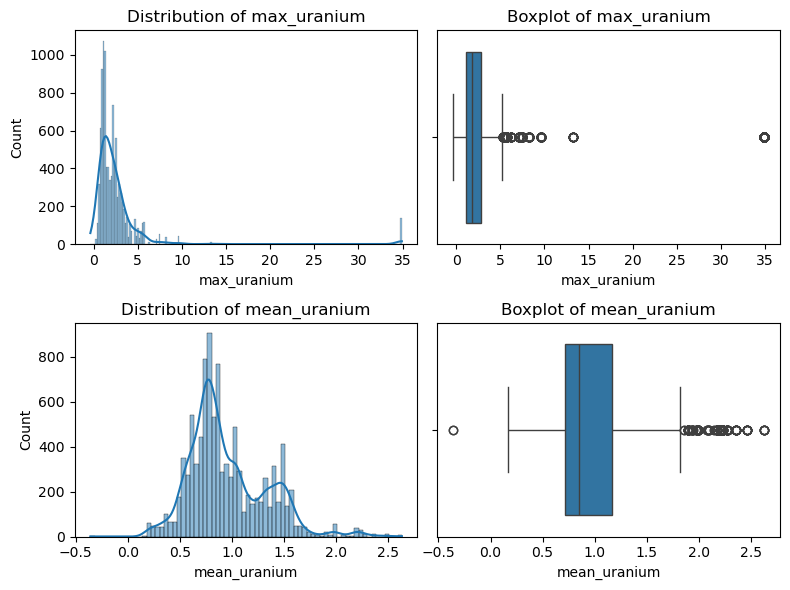

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.histplot(df["max_uranium"].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of max_uranium")

sns.boxplot(x=df["max_uranium"].dropna(), ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of max_uranium")

sns.histplot(df["mean_uranium"].dropna(), kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of mean_uranium")

sns.boxplot(x=df["mean_uranium"].dropna(), ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of mean_uranium")

plt.tight_layout()
plt.show()

max_uranium shows a strongly right-skewed distribution with substantial outliers, so median imputation is more appropriate than mean imputation.

mean_uranium is less skewed and could be imputed by either mean or median, but median imputation is preferred for robustness and consistency.

**Median is used to impute the missing values in max_uranium and mean_uranium**

### Target distribution

##### House-level high-risk distribution

In [77]:
RADON_CONC_HEALTH_RISK = 200
df["radon_danger_conc"] = (df["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)

In [78]:
print(df["radon_danger_conc"].describe())

print("Min:", df["radon_danger_conc"].min())
print("Max:", df["radon_danger_conc"].max())
print("Fraction of zeros:", (df["radon_danger_conc"] == 0).mean())

count    13077.000000
mean         0.112793
std          0.316352
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: radon_danger_conc, dtype: float64
Min: 0
Max: 1
Fraction of zeros: 0.887206545843848


In [79]:
print(df["radon_danger_conc"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

0.00    0.0
0.01    0.0
0.05    0.0
0.25    0.0
0.50    0.0
0.75    0.0
0.95    1.0
0.99    1.0
1.00    1.0
Name: radon_danger_conc, dtype: float64


radon_danger_conc
0    11602
1     1475
Name: count, dtype: int64
radon_danger_conc
0    0.887207
1    0.112793
Name: proportion, dtype: float64


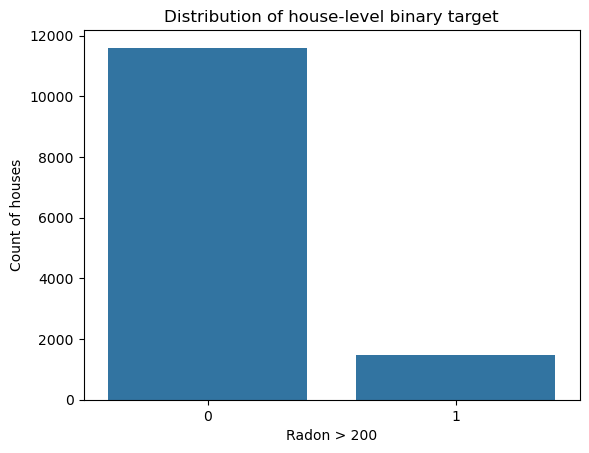

In [80]:
target = "radon_danger_conc"
print(df[target].value_counts(dropna=False))
print(df[target].value_counts(normalize=True, dropna=False))

sns.countplot(x=df[target])
plt.title("Distribution of house-level binary target")
plt.xlabel("Radon > 200")
plt.ylabel("Count of houses")
plt.show()

In [81]:
target = "radon_danger_conc"

counts = df[target].value_counts().sort_index()
props = df[target].value_counts(normalize=True).sort_index()

print("Counts:")
print(counts)

print("\nProportions:")
print(props)

print(f"\nPositive class rate: {props[1]:.3%}")
print(f"Negative class rate: {props[0]:.3%}")
print(f"Imbalance ratio (0:1): {counts[0] / counts[1]:.2f}:1")

Counts:
radon_danger_conc
0    11602
1     1475
Name: count, dtype: int64

Proportions:
radon_danger_conc
0    0.887207
1    0.112793
Name: proportion, dtype: float64

Positive class rate: 11.279%
Negative class rate: 88.721%
Imbalance ratio (0:1): 7.87:1


##### FSA-level aggregated risk distribution

In [82]:
fsa_target = (
    df.groupby("FSA")["radon_danger_conc"]
      .mean()
      .reset_index(name="fsa_risk_fraction")
)

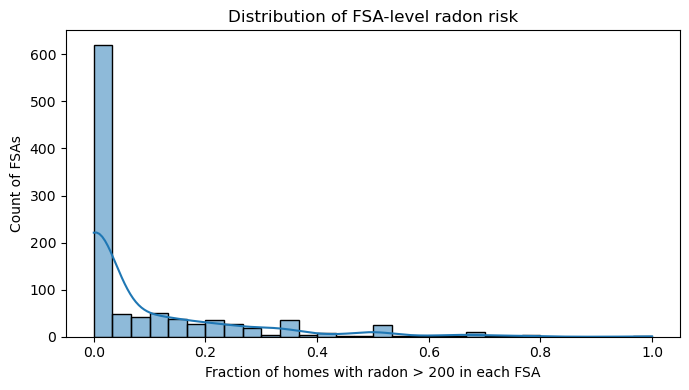

In [83]:
plt.figure(figsize=(7, 4))
sns.histplot(fsa_target["fsa_risk_fraction"], bins=30, kde=True)
plt.title("Distribution of FSA-level radon risk")
plt.xlabel("Fraction of homes with radon > 200 in each FSA")
plt.ylabel("Count of FSAs")
plt.tight_layout()
plt.show()

In [84]:
print(fsa_target["fsa_risk_fraction"].describe())
print(fsa_target["fsa_risk_fraction"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

count    1005.000000
mean        0.087860
std         0.154942
min         0.000000
25%         0.000000
50%         0.000000
75%         0.125000
max         1.000000
Name: fsa_risk_fraction, dtype: float64
0.00    0.000000
0.01    0.000000
0.05    0.000000
0.25    0.000000
0.50    0.000000
0.75    0.125000
0.95    0.428571
0.99    0.666667
1.00    1.000000
Name: fsa_risk_fraction, dtype: float64


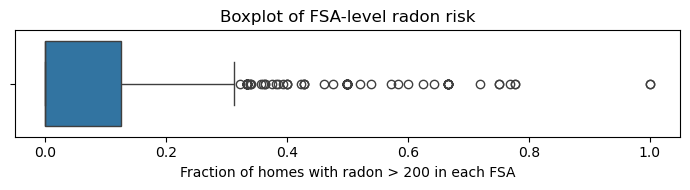

In [85]:
plt.figure(figsize=(7, 2))
sns.boxplot(x=fsa_target["fsa_risk_fraction"])
plt.title("Boxplot of FSA-level radon risk")
plt.xlabel("Fraction of homes with radon > 200 in each FSA")
plt.tight_layout()
plt.show()

The house-level training target is highly imbalanced, with substantially fewer positive cases (radon > 200 Bq/m3) than negative cases. This indicates that most homes in the dataset fall below the health-risk threshold, while elevated-radon homes form a minority class.

Because of this class imbalance, accuracy would be misleading as an evaluation metric. 

After aggregating the binary house-level target within each FSA, the resulting FSA-level radon risk is also highly skewed. Most FSAs have relatively low exceedance fractions, while a smaller number of FSAs show much higher risk levels, producing a long right tail.

### Outlier checks

Simple boxplot-based outlier checks suggest that several variables in the dataset are right-skewed and contain extreme values. This is particularly visible for `max_uranium`, `mean_uranium`, the aggregated FSA-level radon risk, and some representative housing-related variables. At this stage, these observations are recorded for modeling awareness rather than treated as automatic removal candidates.

### Representative feature-target relationships

To explore how selected predictors relate to the training target, we visualized some representative features chosen from the earlier screening results (including MI-based feature prioritization). These plots are intended to provide qualitative insight into how feature distributions differ between homes below and above the 200 Bq/m3 threshold.

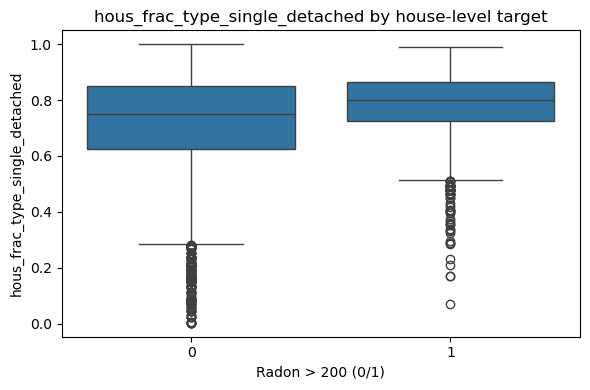

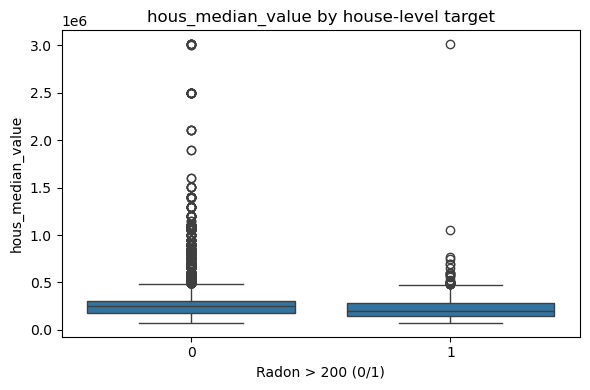

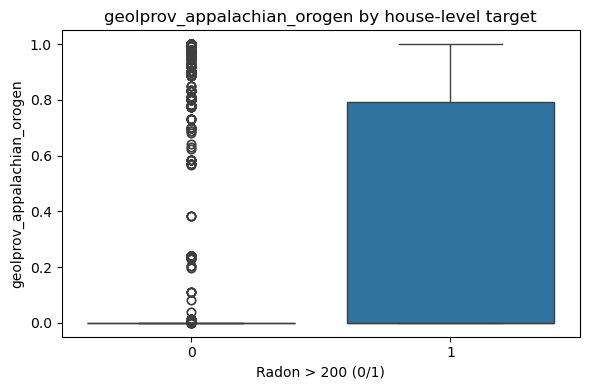

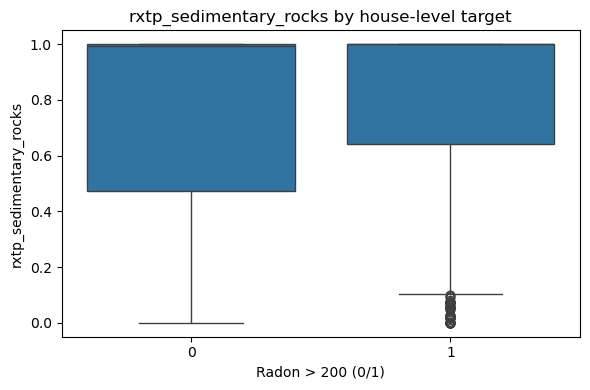

In [86]:
important_num_cols = [
    "hous_frac_type_single_detached",
    "hous_median_value",
    "geolprov_appalachian_orogen",
    "rxtp_sedimentary_rocks",
]

target = "radon_danger_conc"

for col in important_num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"{col} by house-level target")
    plt.xlabel("Radon > 200 (0/1)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Comments on the above reprensentative features:

1. `hous_frac_type_single_detached` (the fraction of single detached houses): 

    Homes in the positive class tend to be associated with slightly higher values of hous_frac_type_single_detached, although the overlap between the two groups remains large.

2. `hous_median_value` (median value of houses):

    Both target groups show strong overlapping distributions of hous_median_value, along with numerous high-end outliers. While this variable may still contribute useful signal in combination with other predictors, its standalone relationship with the binary target appears weak.

3. `geolprov_appalachian_orogen` (the area-weighted proportion of an FSA belonging to the Appalachian Orogen geological province):

    Compared with the previous housing-related variables, geolprov_appalachian_orogen exhibits a more pronounced difference across the two classes, indicating that geological context may be an important contributor to radon risk.

4. `rxtp_sedimentary_rocks` (the area-weighted proportion of an FSA covered by sedimentary rocks):

    rxtp_sedimentary_rocks is generally high in both classes, but the positive class is more concentrated toward the upper end of the range. This pattern suggests that sedimentary rock settings may be associated with higher radon exceedance, although the feature is not uniquely characteristic of the positive class. It may still provide useful signal in combination with other geological and housing variables.

### Correlation and redundancy overview

Some feature groups in this dataset are structurally correlated by construction, especially compositional variables and geological proportion features whose values may sum to one within a feature family. These redundancy patterns are expected and are handled more formally in `reduce_feature.ipynb`, where low-variance filtering, correlation-based pruning, and MI-based feature screening are documented in greater detail.

## Summary

This EDA notebook examined the house-level training data and its connection to the project-level FSA risk objective.

- Missingness was limited and was handled using median imputation for `max_uranium` and `mean_uranium`.

- The house-level binary target (`radon > 200 Bq/m3`) is clearly imbalanced, with positive cases representing a minority of observations.

- When aggregated to the FSA level, the resulting radon risk fraction is strongly right-skewed, with most FSAs showing low exceedance fractions and a smaller number of FSAs exhibiting much higher risk.

- Representative feature-target plots suggest that some housing and geological variables may carry useful predictive signal, although the strength of univariate separation varies across features.

- Several variables also show skewed distributions and visible outliers, which should be kept in mind during modeling.

Formal feature reduction decisions, including low-variance filtering, correlation-based pruning, and MI-based screening, are documented separately in `reduce_feature.ipynb`.